In [65]:
# Importing the Basic libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

warnings.filterwarnings('ignore')

# Importing NPL libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Importing Scikit-learn Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [29]:
# Downloading stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Data Cleaning & Preprocessing

In [30]:
# Loading the CSV file into pandas dataframe.

col_names = ['id','entity','target','text']

df = pd.read_csv(r'/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv',
                 names= col_names,
                 
)

In [31]:
df.head()

,id,entity,target,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [32]:
# Droping the unnecessary columns, which are not important for the model.
df.drop(columns = ['id','entity'], inplace=True)

In [33]:
df.shape

(74682, 2)

In [34]:
# Counting the number of missing values in the dataset
df.isnull().sum()

target      0
text      686
dtype: int64

In [35]:
# Droping all the missing values because i we fill this, that's not gonna help us.
df.dropna(subset='text', inplace = True)

In [36]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [37]:
# Counting the number of duplicated values in the dataset
df.duplicated().sum()

np.int64(4227)

In [38]:
df.drop_duplicates(inplace = True)

In [39]:
df.shape

(69769, 2)

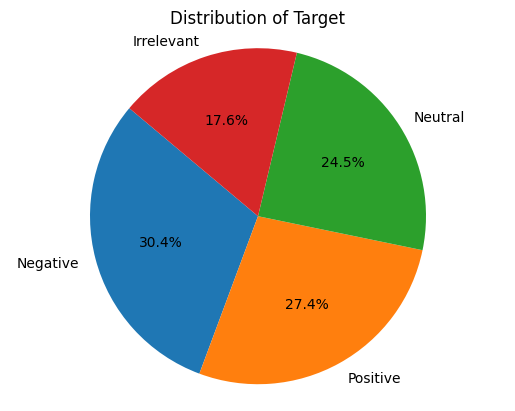

In [40]:
# Distribution of the Target column
dis = df['target'].value_counts()

# Create a pie plot
plt.pie(x=dis, labels=dis.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Target')
plt.axis('equal')
plt.show()

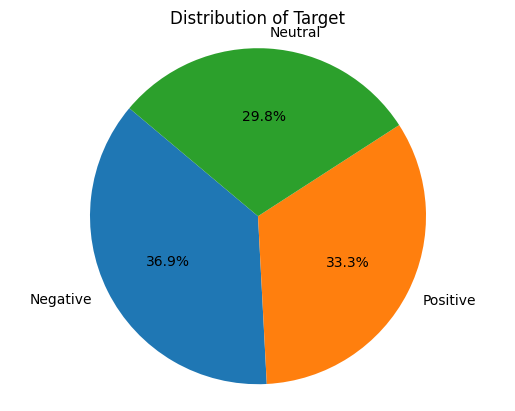

In [41]:
# Distribution of the Target column without Irrelevant

df = df[df['target'] != 'Irrelevant']
dis = df['target'].value_counts()

# Create a pie plot
plt.pie(x=dis, labels=dis.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Target')
plt.axis('equal')
plt.show()

In [42]:
# Now we have to convert the target values into numeric
df['target'] = df['target'].map({'Negative':0, 'Positive':1, 'Neutral':2})

In [43]:
df.head()

,target,text
0,1,im getting on borderlands and i will murder yo...
1,1,I am coming to the borders and I will kill you...
2,1,im getting on borderlands and i will kill you ...
3,1,im coming on borderlands and i will murder you...
4,1,im getting on borderlands 2 and i will murder ...


# Stemming

**Stemming is a process to reduced a word to it's root word**

**example : player, playing, played => play**

In [44]:
import re


def stemming(text):
    # lowercase convert
    text = text.lower()
    # Cleaning the text
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenize the text with split()
    words = text.split()
    # removing stopwords
    stop_words = set(stopwords.words('english'))
    # Stemming the words
    port_stem = PorterStemmer()
    words = [port_stem.stem(word) for word in words if word not in stop_words]

    return ' '.join(words)

df['text'] = df['text'].apply(stemming)

In [45]:
df.head()

,target,text
0,1,im get borderland murder
1,1,come border kill
2,1,im get borderland kill
3,1,im come borderland murder
4,1,im get borderland murder


# Converting Categorical Into Numeric

In [46]:
X = df['text']
y = df['target']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f'X train size: {X_train.shape[0]}' )
print(f'X test size: {X_test.shape[0]}' )
print(f'Y train size: {y_train.shape[0]}' )
print(f'Y train size: {y_test.shape[0]}' )

X train size: 45988
X test size: 11497
Y train size: 45988
Y train size: 11497


In [48]:
vector = TfidfVectorizer(stop_words='english')

X_train_tf = vector.fit_transform(X_train)
X_test_tf = vector.transform(X_test)

# Cross Validation(CV)

In [49]:
models = {
    'LR': LogisticRegression(random_state=42),
    'NB': MultinomialNB(),
    'LGBM': LGBMClassifier(random_state=42, verbose=-1),
    'XGB': XGBClassifier(random_state=42)
}

for name,model in models.items():
    scores = cross_val_score(
        estimator = model,
        X = X_train_tf,
        y = y_train,
        scoring = 'accuracy',
        cv = 5
    )

    print('-*'*15, name, '_*'*15)
    print('CV Scores :', scores)
    print('Accuracy:', np.mean(scores))

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* LR _*_*_*_*_*_*_*_*_*_*_*_*_*_*_*
CV Scores : [0.79941292 0.8072407  0.8116982  0.80982929 0.80939437]
Accuracy: 0.8075150951002368
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* NB _*_*_*_*_*_*_*_*_*_*_*_*_*_*_*
CV Scores : [0.77364644 0.77756034 0.77984344 0.78514733 0.7832989 ]
Accuracy: 0.7798992921555222
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* LGBM _*_*_*_*_*_*_*_*_*_*_*_*_*_*_*
CV Scores : [0.71830833 0.72026528 0.72624484 0.72969447 0.72621507]
Accuracy: 0.7241455949018419
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* XGB _*_*_*_*_*_*_*_*_*_*_*_*_*_*_*
CV Scores : [0.71841705 0.72613612 0.72276582 0.73545721 0.72730238]
Accuracy: 0.7260157155815508


In [62]:
final_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

final_model.fit(X_train_tf, y_train)

final_model.score(X_test_tf, y_test),final_model.score(X_train_tf, y_train)

(0.8258676176393842, 0.8765547534139341)

# Evaluation

In [63]:
y_pred = final_model.predict(X_test_tf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      4168
           1       0.81      0.84      0.83      3863
           2       0.85      0.77      0.80      3466

    accuracy                           0.83     11497
   macro avg       0.83      0.82      0.82     11497
weighted avg       0.83      0.83      0.83     11497



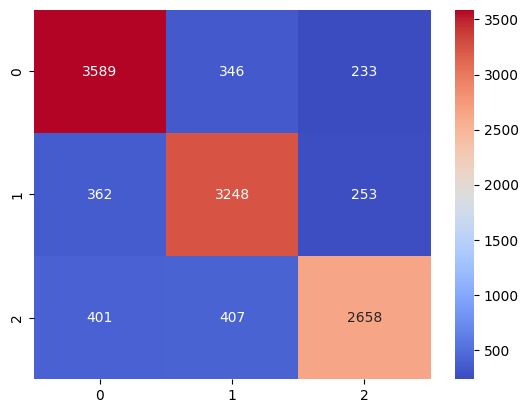

In [64]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.show()

In [68]:
print(joblib.dump(final_model, 'model.pkl'))
print(joblib.dump(vector, 'tfidf.pkl'))

['model.pkl']
['tfidf.pkl']
